## Import The Libraries

In [1]:
!pip install ultralytics

In [2]:
import os
import yaml
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from ultralytics import YOLO
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


In [3]:
class Sys:
    EPOCHS = 40
    BATCH_SIZE = 32
    SEED = 6
    LEARNING_RATE = 0.001
    OPTIMIZER = "Adam"
    TRAIN_IMAGES = "dataset/train/images"
    VALID_IMAGES = "dataset/valid/images"
    TEST_IMAGES = "dataset/test/images"
    OUTPUT_DIR = "ft_models"
    NUM_SAMPLES = 16  # Number of random images for visualization

In [4]:
data_config = {
    "train": Sys.TRAIN_IMAGES,
    "val": Sys.VALID_IMAGES,
    "test": Sys.TEST_IMAGES,
    "nc": 1,  # Number of classes
    "names": ["Brain_Tumor"],  # Class names
}

In [6]:
yaml_file_path = "temp_data.yaml"
with open(yaml_file_path, "w") as file:
    yaml.dump(data_config, file)


In [7]:
def visualize_images(image_folder, num_samples=16):
    image_files = glob(f"{image_folder}/*")
    selected_images = random.sample(image_files, num_samples)
    plt.figure(figsize=(12, 10))
    for i, img_path in enumerate(selected_images):
        plt.subplot(4, 4, i + 1)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.axis('off')
    plt.show()

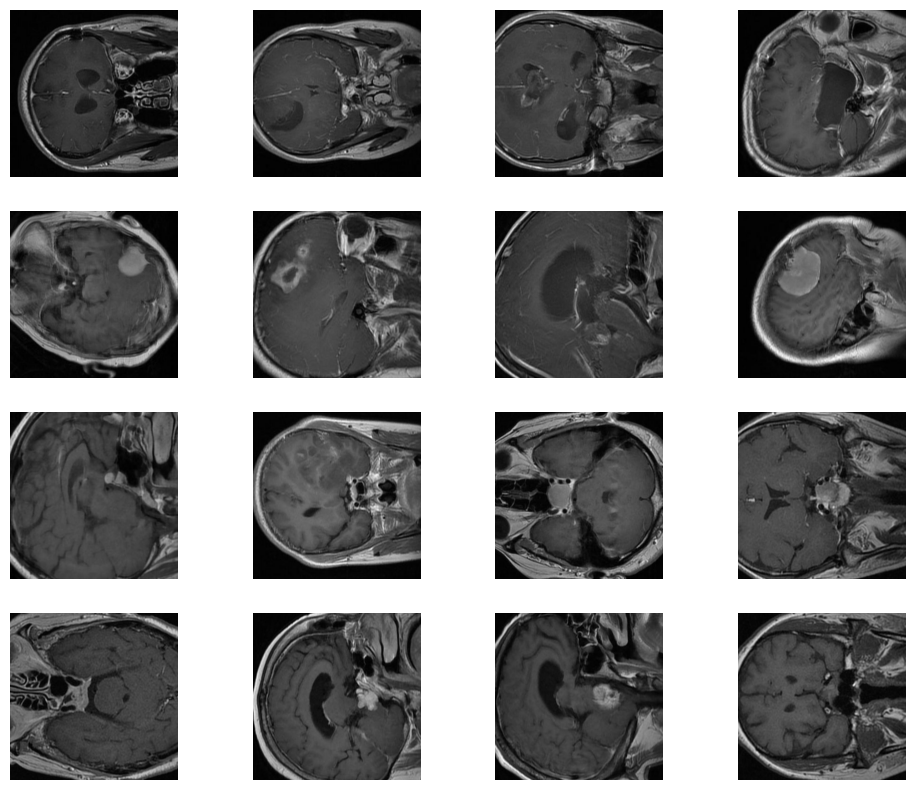

In [8]:
visualize_images(Sys.TRAIN_IMAGES)

In [9]:
model = YOLO("yolov8m.pt")  # Pretrained YOLOv8 model

In [10]:
model.train(
    data=yaml_file_path,
    seed=Sys.SEED,
    epochs=Sys.EPOCHS,
    lr0=Sys.LEARNING_RATE,
    optimizer=Sys.OPTIMIZER,
    project=Sys.OUTPUT_DIR,
    name="brain_tumor_detection",
    verbose=True,
)

New https://pypi.org/project/ultralytics/8.3.59 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.55 🚀 Python-3.12.3 torch-2.5.1+cu124 CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=temp_data.yaml, epochs=40, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=ft_models, name=brain_tumor_detection3, exist_ok=False, pretrained=True, optimizer=Adam, verbose=True, seed=6, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=N

E0000 00:00:1736457762.725165    5683 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1736457762.750409    5683 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics

train: Scanning /home/huzbntu/Stuff/cui/F/Eisha/fyp/doc-link-fyp/ml_models/kidney_stone_detection/using_yolo/dataset/train/labels.cache... 1054 images, 1 backgrounds, 0 corrupt: 100%|██████████| 1054/1054 [00:00<?, ?it/s]
val: Scanning /home/huzbntu/Stuff/cui/F/Eisha/fyp/doc-link-fyp/ml_models/kidney_stone_detection/using_yolo/dataset/valid/labels.cache... 123 images, 0 backgrounds, 0 corrupt: 100%|██████████| 123/123 [00:00<?, ?it/s]

Plotting labels to ft_models/brain_tumor_detection3/labels.jpg... 


...

                   all        123        325      0.818       0.72      0.768      0.318



40 epochs completed in 17.586 hours.
Optimizer stripped from ft_models/brain_tumor_detection3/weights/last.pt, 52.0MB
Optimizer stripped from ft_models/brain_tumor_detection3/weights/best.pt, 52.0MB

Validating ft_models/brain_tumor_detection3/weights/best.pt...
Ultralytics 8.3.55 🚀 Python-3.12.3 torch-2.5.1+cu124 CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)
Model summary (fused): 218 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:46<00:00, 11.74s/it]


                   all        123        325      0.826      0.738      0.786      0.329
Speed: 1.2ms preprocess, 374.6ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to ft_models/brain_tumor_detection3


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x74f9d5ad9010>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [9]:
# Cleanup the temporary YAML file if needed
import os
os.remove(yaml_file_path)

In [17]:
# Save the trained model for future use
trained_model_path = f"{Sys.OUTPUT_DIR}/brain_tumor_detection3/weights/best.pt"
model_trained = YOLO("ft_models/brain_tumor_detection3/weights/best.pt")

In [19]:
def stone_detection(img_path, model, save_path=None):
    img = cv2.imread(img_path)  # Load image
    results = model(img)  # Perform inference
    detect_img = results[0].plot()  # Add bounding boxes to the image

    if save_path:
        cv2.imwrite(save_path, detect_img)  # Save the output image
    return cv2.cvtColor(detect_img, cv2.COLOR_BGR2RGB)  # Convert for display

In [20]:
test_images_path = Sys.TEST_IMAGES
test_images = os.listdir(test_images_path)
selected_images = random.sample(test_images, Sys.NUM_SAMPLES)

In [21]:
output_dir = "predicted_images"
os.makedirs(output_dir, exist_ok=True)


0: 640x640 (no detections), 430.1ms
Speed: 1.4ms preprocess, 430.1ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Brain_Tumor, 379.8ms
Speed: 1.8ms preprocess, 379.8ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Brain_Tumor, 418.3ms
Speed: 1.5ms preprocess, 418.3ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 525.7ms
Speed: 1.5ms preprocess, 525.7ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 5 Brain_Tumors, 480.0ms
Speed: 8.1ms preprocess, 480.0ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 424.6ms
Speed: 1.4ms preprocess, 424.6ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Brain_Tumor, 451.8ms
Speed: 4.2ms preprocess, 451.8ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Brain_Tumor, 450.0ms
Speed: 7.9ms preprocess, 45

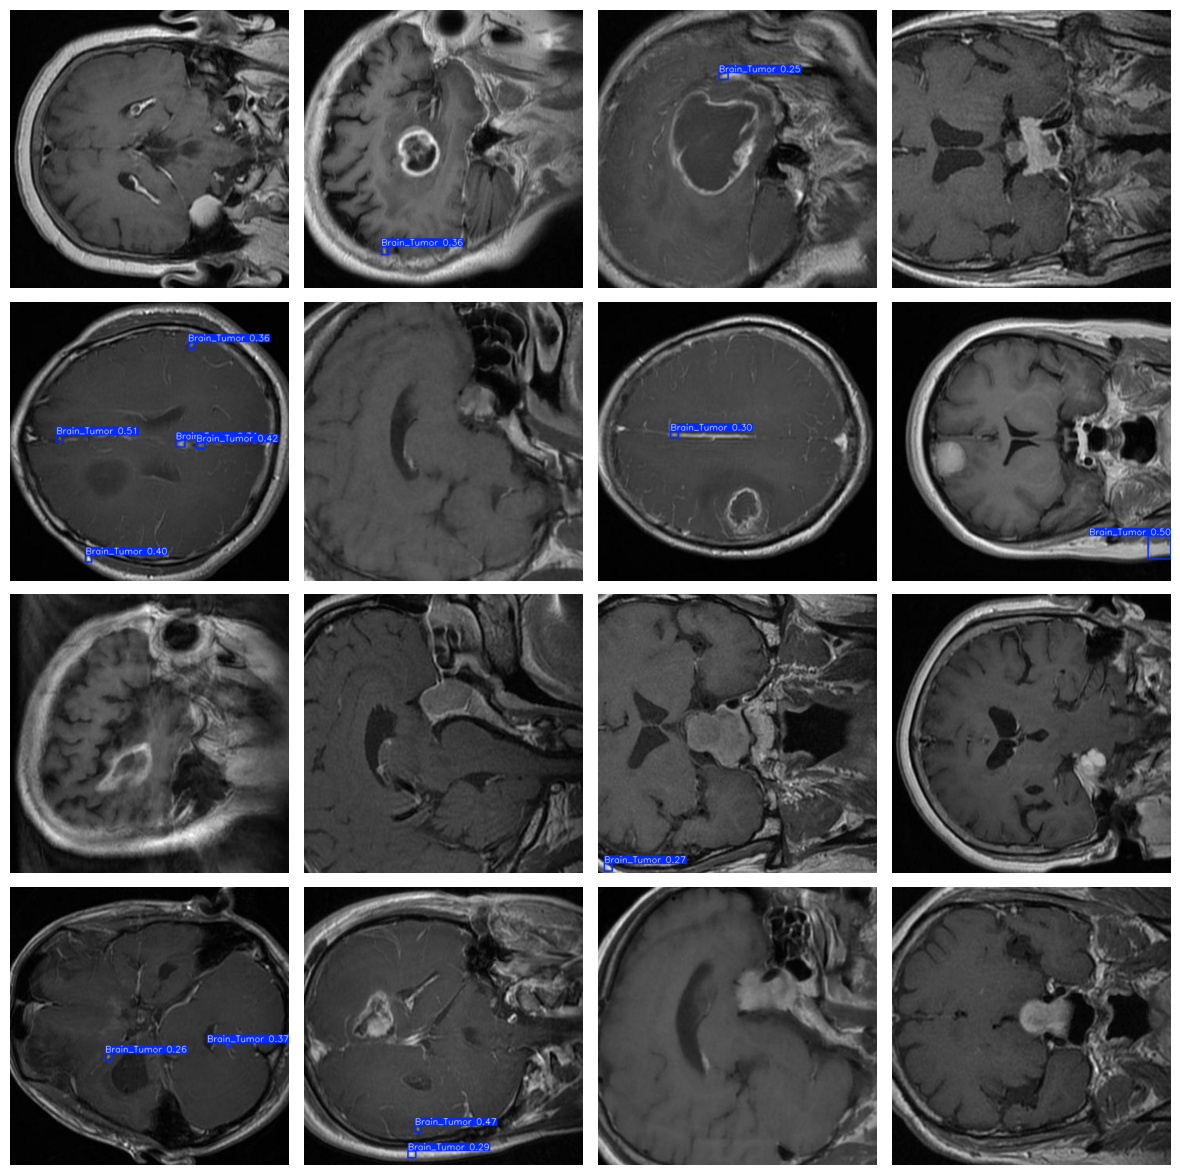

In [22]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(15, 15))
for i, img_file in enumerate(selected_images):
    row_idx = i // 4
    col_idx = i % 4
    img_path = os.path.join(test_images_path, img_file)
    save_path = os.path.join(output_dir, f"predicted_{img_file}")
    detect_img = stone_detection(img_path, model_trained, save_path=save_path)
    axes[row_idx, col_idx].imshow(detect_img)
    axes[row_idx, col_idx].axis("off")
plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()

In [23]:
def evaluate_model(model_path, test_images_path):
    model = YOLO(model_path)  # Load trained model
    image_files = glob(f"{test_images_path}/*.jpg")
    
    y_true = []  # True labels
    y_pred = []  # Predicted labels

    for img_path in image_files:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Get predictions
        results = model(img)

        # Assuming one class, process the predictions for label assignment
        for result in results:
            if result.boxes.shape[0] > 0:
                y_pred.append(1)  # Predicted kidney stone
            else:
                y_pred.append(0)  # No kidney stone

        # Add ground truth label from filename or annotations
        # (Modify this logic based on how ground truths are stored)
        true_label = 1 if "kidney_stone" in img_path else 0
        y_true.append(true_label)

    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)

    print("Confusion Matrix:")
    print(cm)
    print("\nAccuracy:", acc)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["No Kidney Stone", "Kidney Stone"]))

    return cm, acc

In [24]:
model_path = "ft_models/brain_tumor_detection3/weights/best.pt"
test_images_path = Sys.TEST_IMAGES
conf_matrix, accuracy = evaluate_model(model_path, test_images_path)


0: 640x640 (no detections), 388.8ms
Speed: 8.7ms preprocess, 388.8ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 517.9ms
Speed: 1.5ms preprocess, 517.9ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 384.2ms
Speed: 4.5ms preprocess, 384.2ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Brain_Tumor, 472.6ms
Speed: 1.6ms preprocess, 472.6ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 3 Brain_Tumors, 371.9ms
Speed: 1.6ms preprocess, 371.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 385.3ms
Speed: 3.1ms preprocess, 385.3ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 407.5ms
Speed: 2.0ms preprocess, 407.5ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 382.9ms
Speed: 1.5ms preproce

/home/huzbntu/Stuff/cui/F/Eisha/fyp/doc-link-fyp/ml_models/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/huzbntu/Stuff/cui/F/Eisha/fyp/doc-link-fyp/ml_models/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/huzbntu/Stuff/cui/F/Eisha/fyp/doc-link-fyp/ml_models/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control